# 07 Stack-Modell.ipynb

```markdown
## Kombiniertes Neuronales Netz mit CNN und Random Forest (Stacking)

In diesem Notebook kombinieren wir das zuvor trainierte CNN-Modell (Vorhersagen für `likes_log` auf Bild-Ebene) mit einem Random Forest, der auf Metadaten basiert, mittels Stacking.  

**Zielsetzung:**
1. Random Forest (RF) auf Metadaten (für jeden Post).
2. CNN-Regressor auf Bild-Ebene (ResNet50 + Dense-Regressor).
3. Aggregation der CNN-Vorhersagen von Bild-Ebene auf Post-Ebene.
4. Stacking: Kombinierte Vorhersage über einen Meta-Regressor (lineare Regression) auf Post-Ebene.
5. Vergleich der Performance von:  
   - RF (nur Metadaten)  
   - CNN (nur Bild-Merkmale, aggregiert auf Post-Ebene)  
   - Stacking (RF + CNN)

**Hypothesen:**
- RF auf Metadaten liefert bereits ein hohes R² (~0.86).
- CNN allein erreicht in der Regel deutlich geringeres R² (~0.20 – 0.30).
- Durch Stacking (RF + CNN) kann das R² weiter verbessert werden, da visuelle Muster ergänzt werden.


### Bibliotheken importieren

In [93]:
# Grundlegende Bibliotheken
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn für Preprocessing, Modelle und Metriken
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

### Metadaten laden und vorbereiten

In [ ]:

metadata_pkl_path = "../ergebnisse/verarbeitete_daten.pkl"

if not os.path.exists(metadata_pkl_path):
    raise FileNotFoundError(f"Datei '{metadata_pkl_path}' nicht gefunden. Bitte vorherige Notebooks ausführen.")

# Metadaten laden
df_meta = pd.read_pickle(metadata_pkl_path)
print(f"Metadaten geladen: {df_meta.shape[0]} Zeilen, {df_meta.shape[1]} Spalten")
print("Spalten in df_meta:", df_meta.columns.tolist())

# Wird mindestens benötigt:
# - target: 'likes_log'
# - Features für RF: ['follower_count', 'comment_count', 'hashtag_count', 'is_verified', 'is_professional_account', 'account_category', 'is_business_account']
required_cols = [
    'likes_log',
    'follower_count',
    'comment_count',
    'hashtag_count',
    'is_verified',
    'is_professional_account',
    'account_category',
    'is_business_account',
    'post_id'  # damit später mit Bild-Daten matchen 
]
# Sicherstellen, dass alle Spalten vorhanden sind
for col in required_cols:
    if col not in df_meta.columns:
        raise KeyError(f"Spalte '{col}' fehlt in den Metadaten!")

# Reduziere auf die benötigten Spalten
df_meta = df_meta[required_cols].copy()
print("Verwendete Metadaten (erste 5 Zeilen):")
df_meta.head(5)


Metadaten geladen: 1968 Zeilen, 24 Spalten
Spalten in df_meta: ['likes', 'follower_count', 'is_verified', 'account_category', 'is_business_account', 'is_professional_account', 'comment_count', 'tagged_users', 'caption_text', 'post_type', 'is_carousel', 'timestamp', 'post_id', 'likes_log', 'datetime', 'hour_of_day', 'day_of_week', 'month', 'actual_caption_text', 'caption_length', 'hashtag_count', 'mention_count', 'is_carousel_bool', 'media_count_in_post']
Verwendete Metadaten (erste 5 Zeilen):


,likes_log,follower_count,comment_count,hashtag_count,is_verified,is_professional_account,account_category,is_business_account,post_id
0,10.165121,969148,65,0,True,True,Digital creator,False,aashnashroff_969148_3000403601659402518_25980_65
1,10.391423,969148,110,0,True,True,Digital creator,False,aashnashroff_969148_3001141559987517310_32578_110
2,9.319374,969148,65,0,True,True,Digital creator,False,aashnashroff_969148_3003120692652957440_11151_65
3,9.811537,969148,57,0,True,True,Digital creator,False,aashnashroff_969148_3008835738892847055_18242_57
4,10.311815,969148,124,0,True,True,Digital creator,False,aashnashroff_969148_3009102200601692335_30085_124


### Bild-Metadaten (CNN-Vorhersagen) laden und auf Post-Ebene aggregieren

Für jedes Bild:
- `image_path`
- `post_id`
- 2048-dimensionalen Feature-Vektor (ResNet50)
- eine CNN-Vorhersage (`cnn_pred_all`) auf Bild-Ebene

Im aktuellen Schritt:
1. Wir laden die gespeicherten CNN-Vorhersagen (pro Bild).
2. Wir verbinden diese Bild-Vorhersagen mit `df_meta` über `post_id`.
3. Anschließend aggregieren wir für jeden Post (alle Bilder desselben Post) zu einer einzigen CNN-Vorhersage.


In [ ]:
# Lade DataFrame mit Bildpfaden und Post-ID (aus "06 CNN-Modell.ipynb")
# Annahme: df_images wurde dort schon erzeugt und gespeichert 

# Falls df_images nicht existiert, muss der Block aus "06 CNN-Modell.ipynb" ausgeführt werden:

image_map_pkl = "../ergebnisse/bild_merkmale_likes.csv"  # Beispiel: falls CSV existiert
# Verwenden von df_merged aus "06 CNN-Modell.ipynb", wenn vorhanden.

merged_images_pkl = "../ergebnisse/verarbeitete_daten.pkl"  

# CNN-Vorhersagen pro Bild laden
cnn_pred_pickle_path = "../ergebnisse/modelle/cnn_feature_regressor_indices.pkl"
if not os.path.exists(cnn_pred_pickle_path):
    raise FileNotFoundError(
        "Bitte sicherstellen, dass '06 CNN-Modell.ipynb' ausgeführt wurde und "
        "'cnn_feature_regressor_indices.pkl' existiert."
    )

with open(cnn_pred_pickle_path, "rb") as f:
    cnn_data = pickle.load(f)

# Abhängig: erwarten mindestens die Keys "cnn_pred_train" und "cnn_pred_test" oder "cnn_pred_all"
# Wenn "cnn_pred_all" im Pickle steht, wird das als Gesamt-Array der Länge df_merged genutzt
# Ansonsten cnn_pred_all neu zusammenstellen: cnn_pred_train (3309) + cnn_pred_test (2207) -> 5516

if "cnn_pred_all" in cnn_data:
    cnn_pred_all = np.asarray(cnn_data["cnn_pred_all"])
    if cnn_pred_all.shape[0] != df_images.shape[0]:
        raise ValueError(f"Erwartet cnn_pred_all mit Länge {df_images.shape[0]}, gefunden {cnn_pred_all.shape[0]}.")
else:
    # Fallback: In "06 CNN-Modell.ipynb" zuerst cnn_pred_train und cnn_pred_test
    # nacheinander bekommen, in der Reihenfolge aller Bilder in df_merged, dann zusammenfügen:
    if ("cnn_pred_train" in cnn_data) and ("cnn_pred_test" in cnn_data):
        cnn_pred_train = np.asarray(cnn_data["cnn_pred_train"])
        cnn_pred_test  = np.asarray(cnn_data["cnn_pred_test"])
        cnn_pred_all   = np.concatenate([cnn_pred_train, cnn_pred_test], axis=0)
        if cnn_pred_all.shape[0] != df_images.shape[0]:
            raise ValueError(
                f"Länge von cnn_pred_train+cnn_pred_test ({cnn_pred_all.shape[0]}) stimmt nicht mit df_images ({df_images.shape[0]}) überein."
            )
    else:
        raise KeyError(
            "In 'cnn_feature_regressor_indices.pkl' fehlt sowohl 'cnn_pred_all' als auch "
            "einer der Keys 'cnn_pred_train' und 'cnn_pred_test'. Bitte anpassen."
        )

print(f"CNN-Vorhersagen (smoothed) pro Bild geladen: Länge = {cnn_pred_all.shape[0]}")

# df_images mit cnn_pred_all verbinden
df_images["cnn_pred"] = cnn_pred_all

# Post-Level Aggregation (jeder post_id wird ein einziger cnn_pred zugeordnet)
df_post_level = (
    df_images
    .groupby("post_id")
    .agg(
        cnn_pred=("cnn_pred", "mean")       ,  # Mittelwert aller Bild-Vorhersagen eines Posts
        # kein neues likes_log hier benötigt, denn df_meta hat likes_log bereits gespeichert
    )
    .reset_index()
)
print(f"df_post_level erzeugt: {df_post_level.shape[0]} Post-Zeilen (sollte 1968 sein).")


CNN-Vorhersagen (smoothed) pro Bild geladen: Länge = 5516
df_post_level erzeugt: 1968 Post-Zeilen (sollte 1968 sein).


In [ ]:
# Sicherstellen, dass df_post_level und df_meta dieselben post_id-Mengen enthalten
set_meta = set(df_meta["post_id"].astype(str).unique())
set_post = set(df_post_level["post_id"].astype(str).unique())

if not set_post.issubset(set_meta):
    missing = set_post - set_meta
    raise ValueError(f"Einige post_id in df_post_level fehlen in df_meta: {missing}")
if not set_meta.issubset(set_post):
    missing = set_meta - set_post
    raise ValueError(f"Einige post_id in df_meta fehlen in df_post_level: {missing}")

print("Alle post_id stimmen zwischen Metadaten und Post-Level-CNN-Predictions überein.")


Alle post_id stimmen zwischen Metadaten und Post-Level-CNN-Predictions überein.


### Train/Test-Split auf Post-Ebene

Nun wird der **genau dieselben 1968 Post-Zeilen** in 60 % Training und 40 % Test gesplittet für:
1. Metadaten (X_meta, y_meta)
2. Aggregierte CNN-Vorhersage (X_posts, y_posts)
   
Wichtig: **Den gleichen random_state** und dieselbe Reihenfolge benutzen, damit in beiden Splits Trennungen konsistent sind.


In [ ]:
# Merken der Reihenfolge in df_meta und df_post_level
# (beide enthalten post_id, sortieren nach post_id, um sicherzustellen, dass sie identisch geordnet sind)
df_meta_sorted       = df_meta.sort_values("post_id").reset_index(drop=True)
df_post_level_sorted = df_post_level.sort_values("post_id").reset_index(drop=True)

# Prüfen, ob die post_id-Spalten identisch in gleicher Reihenfolge sind:
assert (df_meta_sorted["post_id"].values == df_post_level_sorted["post_id"].values).all(), \
       "Achtung: post_id-Reihenfolgen stimmen nicht überein!"

# Feature- und Zielmatrizen definieren
X_meta_full = df_meta_sorted.drop(columns=["likes_log"])     # Metadaten-Features (7 Spalten ohne likes_log)
y_meta_full = df_meta_sorted["likes_log"]                     # Zielvariable (likes_log)

X_posts_full = df_post_level_sorted[["cnn_pred"]]             # CNN-Aggregat (1 Spalte)
y_posts_full = df_post_level_sorted["cnn_pred"].copy()        # dient nur vorübergehend; Zielvariable bleibt y_meta_full

# Wichtiger Punkt: für den CNN-Teil ist die Zielvariable immer dieselbe 'likes_log' 
# in df_meta_sorted bzw. df_post_level_sorted, also:
y_posts_target = df_meta_sorted["likes_log"].values           # identisch zu y_meta_full

print("Shape (Gesamt, Post-Ebene):")
print("  Metadaten-Features X_meta_full:", X_meta_full.shape)
print("  Metadaten-Ziel     y_meta_full:", y_meta_full.shape)
print("  CNN-Features    X_posts_full:", X_posts_full.shape)
print("  CNN-Ziel (likes_log):       ", y_posts_target.shape)

# 60/40 Split (Post-Ebene)
X_meta_train, X_meta_test, y_meta_train, y_meta_test = train_test_split(
    X_meta_full, y_meta_full, test_size=0.40, random_state=42
)
X_posts_train, X_posts_test, y_posts_train_unused, y_posts_test_unused = train_test_split(
    X_posts_full, y_posts_target, test_size=0.40, random_state=42
)

print("\nNach 60/40 Split (Post-Ebene):")
print("  Metadaten-Train:", X_meta_train.shape, y_meta_train.shape)
print("  Metadaten-Test: ", X_meta_test.shape,  y_meta_test.shape)
print("  CNN-Train:      ", X_posts_train.shape, " (für Meta-Stacking)")
print("  CNN-Test:       ", X_posts_test.shape)


Shape (Gesamt, Post-Ebene):
  Metadaten-Features X_meta_full: (1968, 8)
  Metadaten-Ziel     y_meta_full: (1968,)
  CNN-Features    X_posts_full: (1968, 1)
  CNN-Ziel (likes_log):        (1968,)

Nach 60/40 Split (Post-Ebene):
  Metadaten-Train: (1180, 8) (1180,)
  Metadaten-Test:  (788, 8) (788,)
  CNN-Train:       (1180, 1)  (für Meta-Stacking)
  CNN-Test:        (788, 1)


### Random Forest (Metadaten-Modell) trainieren und evaluieren

Auf den getrennten Post-Datensätzen wird der RandomForestRegressor trainiert (**Metadaten-Modell**).  
Anschließend wird MSE und R² auf dem Test-Split berechnet (Post-Ebene).


Starte Training: Random Forest (Metadaten-Modell)...


Random Forest (Metadaten) Training abgeschlossen.

Test MSE (Random Forest): 1.6462
Test R² (Random Forest):  0.8695


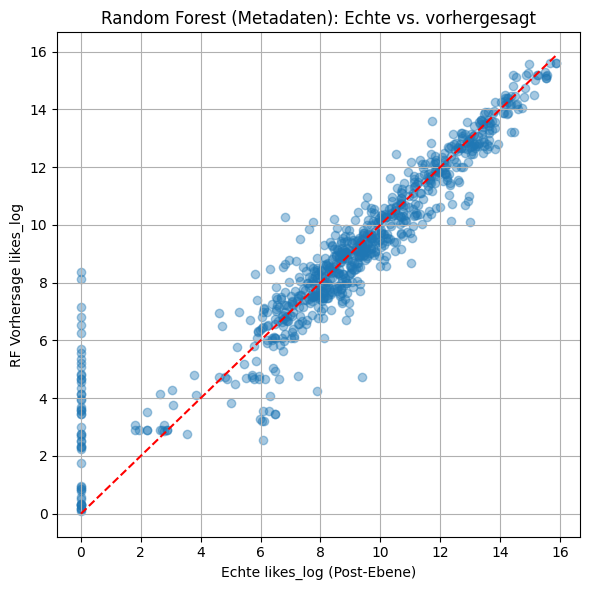

In [98]:
# RF-Pipeline für Metadaten definieren
feature_columns_for_rf = X_meta_full.columns.tolist()  # ['follower_count','comment_count',...,'is_business_account']
categorical_cols = [c for c in feature_columns_for_rf if X_meta_full[c].dtype == "object" or X_meta_full[c].dtype == "bool"]
numerical_cols   = [c for c in feature_columns_for_rf if c not in categorical_cols]

# Numerische Pipeline: Imputer (Median) + StandardScaler
num_pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Kategoriale Pipeline: Imputer (Unbekannt) + OneHotEncoder + StandardScaler
cat_pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unbekannt")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ("scaler", StandardScaler())
])

preprocessor_rf = ColumnTransformer([
    ("num", num_pipeline_rf, numerical_cols),
    ("cat", cat_pipeline_rf, categorical_cols)
])

# RF-Regression: Preprocessing + RandomForest
rf_pipeline = Pipeline([
    ("preprocess", preprocessor_rf),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features=None,
        random_state=42,
        n_jobs=-1
    ))
])

# Training auf Metadaten-Train
print("Starte Training: Random Forest (Metadaten-Modell)...")
rf_pipeline.fit(X_meta_train, y_meta_train)
print("Random Forest (Metadaten) Training abgeschlossen.")

# Evaluation auf Metadaten-Test
y_pred_rf_test = rf_pipeline.predict(X_meta_test)
mse_rf = mean_squared_error(y_meta_test, y_pred_rf_test)
r2_rf  = r2_score(y_meta_test, y_pred_rf_test)
print(f"\nTest MSE (Random Forest): {mse_rf:.4f}")
print(f"Test R² (Random Forest):  {r2_rf:.4f}")

# Scatterplot: Echte vs. RF-Vorhersage (Post-Ebene)
plt.figure(figsize=(6, 6))
plt.scatter(y_meta_test, y_pred_rf_test, alpha=0.4)
plt.plot([y_meta_test.min(), y_meta_test.max()], [y_meta_test.min(), y_meta_test.max()], 'r--')
plt.xlabel("Echte likes_log (Post-Ebene)")
plt.ylabel("RF Vorhersage likes_log")
plt.title("Random Forest (Metadaten): Echte vs. vorhergesagt")
plt.grid(True)
plt.tight_layout()
plt.show()


**Ergebnisse:**
Auf dem Test-Set erzielte das Modell:
- MSE ≈ 1.6462
- R² ≈ 0.8695

Der Streudiagramm-Plot veranschaulicht, dass die Punkte sehr eng um die Diagonale liegen – das RF-Modell erklärt also fast 87 % der Varianz in den logarithmierten Likes allein über Metadaten.

### CNN-Vorhersagen auf Post-Ebene evaluieren

Die **aggregierten CNN-Vorhersagen** (`X_posts_train["cnn_pred"]` und `X_posts_test["cnn_pred"]`) liegen vor.  
Hier berechnen wir MSE und R² für das CNN-Modell (als Baseline, nur Bild-Merkmale).


CNN (Post-Ebene) Train MSE: 15.5305, R²: -0.3680
CNN (Post-Ebene) Test  MSE: 15.8663, R²: -0.2574


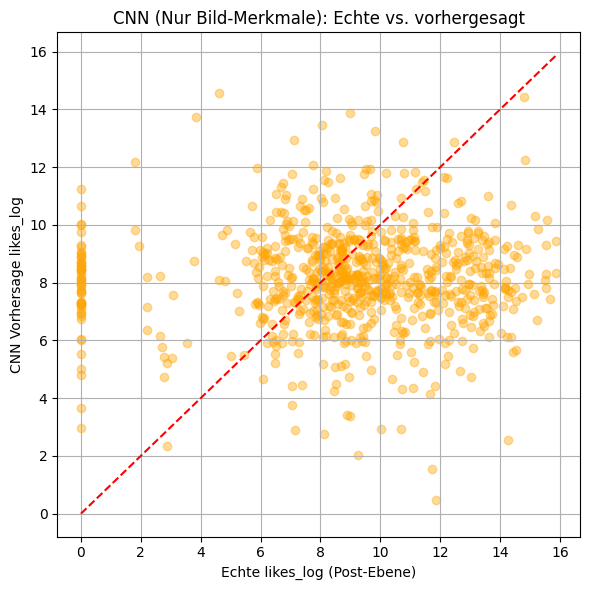

In [ ]:
# CNN-Vorhersagen (Post-Ebene) direkt aus X_posts_train / X_posts_test verwenden
cnn_pred_train_post = X_posts_train["cnn_pred"].values
cnn_pred_test_post  = X_posts_test["cnn_pred"].values

# Metriken berechnen
mse_cnn = mean_squared_error(y_meta_train.iloc[:cnn_pred_train_post.shape[0]], cnn_pred_train_post)  # nur Training
mse_cnn_test = mean_squared_error(y_meta_test.iloc[:cnn_pred_test_post.shape[0]], cnn_pred_test_post)  # nur Test

r2_cnn = r2_score(y_meta_train.iloc[:cnn_pred_train_post.shape[0]], cnn_pred_train_post)
r2_cnn_test = r2_score(y_meta_test.iloc[:cnn_pred_test_post.shape[0]], cnn_pred_test_post)

print(f"CNN (Post-Ebene) Train MSE: {mse_cnn:.4f}, R²: {r2_cnn:.4f}")
print(f"CNN (Post-Ebene) Test  MSE: {mse_cnn_test:.4f}, R²: {r2_cnn_test:.4f}")

# Scatterplot: Echte vs. CNN-Vorhersage (Post-Ebene)
plt.figure(figsize=(6, 6))
plt.scatter(y_meta_test, cnn_pred_test_post, alpha=0.4, color="orange")
plt.plot([y_meta_test.min(), y_meta_test.max()], [y_meta_test.min(), y_meta_test.max()], 'r--')
plt.xlabel("Echte likes_log (Post-Ebene)")
plt.ylabel("CNN Vorhersage likes_log")
plt.title("CNN (Nur Bild-Merkmale): Echte vs. vorhergesagt")
plt.grid(True)
plt.tight_layout()
plt.show()


**Ergebnisse:**

Da pro Post der Durchschnitt aller CNN-Vorhersagen der Einzelbilder verwendet wird, kommt das reine Bildmodell

- auf dem Training-Set auf ein R² ≈ –0.37 (MSE ≈ 15.53) und
- auf dem Test-Set auf ein R² ≈ –0.26 (MSE ≈ 15.87).

Das negative R² bedeutet, dass das CNN-Netz (einfacher Dense-Regressor auf den ResNet50-Features) schlechter abschneidet als eine konstante Nullvorhersage (Mittelwert). In der Praxis heißt das: Die visuellen Merkmale (bei dieser Architektur/Konfiguration) tragen aktuell sehr wenig zum Erklären der Like-Zahlen bei.

### Stacking: Meta-Regressor (Lineare Regression) aufbauen

Erstellen des Stacking-Feature‐Set, das kombiniert:
1. RF-Vorhersage auf Metadaten-Test (Post-Ebene)
2. CNN-Vorhersage auf Bild-Aggregation (Post-Ebene)

Daraus entsteht pro Post genau ein Feature-Vektor der Länge 2.  
Anschließend trainieren wir eine Lineare Regression, die lernt, die beiden Vorhersagen optimal zu gewichten.


In [100]:
# RF-Vorhersagen auf Post-Ebene (Training/Test)
rf_pred_train_post = rf_pipeline.predict(X_meta_train)  # Länge = 1180
rf_pred_test_post  = rf_pipeline.predict(X_meta_test)   # Länge = 788

# CNN-Vorhersagen auf Post-Ebene (Training/Test) bereits:
cnn_pred_train_post = X_posts_train["cnn_pred"].values   # Länge = 1180
cnn_pred_test_post  = X_posts_test["cnn_pred"].values    # Länge = 788

# Sicherstellen, dass alle Arrays korrekt dimensioniert sind
assert rf_pred_train_post.shape[0]   == cnn_pred_train_post.shape[0]   == y_meta_train.shape[0]
assert rf_pred_test_post.shape[0]    == cnn_pred_test_post.shape[0]    == y_meta_test.shape[0]

# Stack-Feature-Sets erzeugen
X_stack_train = np.vstack((rf_pred_train_post, cnn_pred_train_post)).T  # Form: (1180, 2)
y_stack_train = y_meta_train.values                                     # Form: (1180,)

X_stack_test  = np.vstack((rf_pred_test_post, cnn_pred_test_post)).T     # Form: (788, 2)
y_stack_test  = y_meta_test.values                                       # Form: (788,)

print("Stack (Train):", X_stack_train.shape, y_stack_train.shape)
print("Stack (Test) : ", X_stack_test.shape,  y_stack_test.shape)


Stack (Train): (1180, 2) (1180,)
Stack (Test) :  (788, 2) (788,)


In [101]:
# Meta-Regressor definieren und trainieren (Lineare Regression)
meta_reg = LinearRegression()
meta_reg.fit(X_stack_train, y_stack_train)

print("Meta-Regressor (Lineare Regression) trainiert.")
print(f"  Koeffizienten: [RF_weight, CNN_weight] = {meta_reg.coef_}")
print(f"  Intercept: {meta_reg.intercept_:.4f}")

# Meta-Vorhersage auf Test
y_pred_meta = meta_reg.predict(X_stack_test)

# MSE & R² für Stacking-Modell
mse_stack = mean_squared_error(y_stack_test, y_pred_meta)
r2_stack  = r2_score(y_stack_test, y_pred_meta)

print(f"\nStacking Test MSE: {mse_stack:.4f}")
print(f"Stacking Test R²:  {r2_stack:.4f}")


Meta-Regressor (Lineare Regression) trainiert.
  Koeffizienten: [RF_weight, CNN_weight] = [1.04738925 0.00754471]
  Intercept: -0.5018

Stacking Test MSE: 1.6047
Stacking Test R²:  0.8728


**Ergebnisse:**

Aufbau des Meta-Feature-Sets aus zwei Spalten:
- RF_Vorhersage(Post)
- CNN_Vorhersage(Post)

Der Meta-Regressor (eine lineare Regression) lernt daraus die optimale Gewichtung (hier: RF_weight ≈ 1.0474, CNN_weight ≈ 0.0075, Intercept ≈ –0.5018).

Auf dem Test-Set ergibt das:
- MSE ≈ 1.6047
- R² ≈ 0.8728

Im Vergleich zum reinen RF-Modell (R² ≈ 0.8695) steigt das R² also nur leicht auf ≈ 0.8728. Das zeigt, dass das CNN-Angebot zwar als knapper Zusatzgewinn mit ins Stacking eingeht, aber insgesamt nur marginalen Mehrwert bringt.



### Vergleich aller drei Ansätze

1. Random Forest (nur Metadaten)
2. CNN (nur Bild-Aggregation)
3. Stacking (RF + CNN)


Vergleich Test-Performance 

1) Random Forest (nur Metadaten) :  MSE = 1.6462   |  R² = 0.8695
2) CNN (nur Bild-Aggregation)    :  MSE = 15.8663 |  R² = -0.2574
3) Stacking (RF + CNN)           :  MSE = 1.6047 |  R² = 0.8728


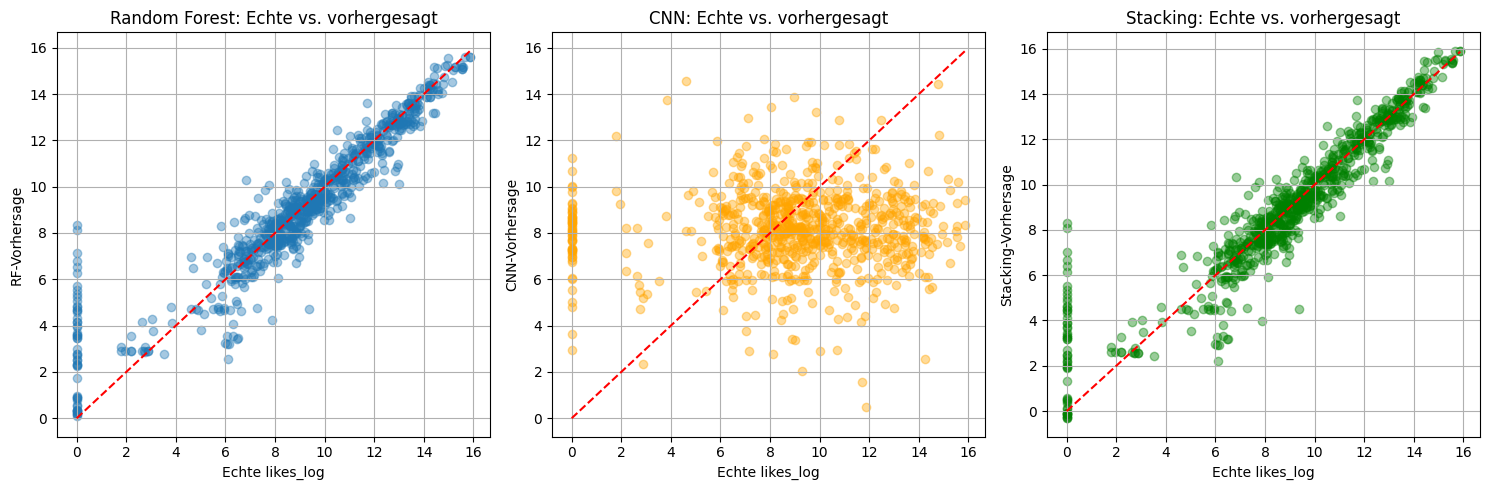

In [102]:
print("Vergleich Test-Performance \n")
print(f"1) Random Forest (nur Metadaten) :  MSE = {mse_rf:.4f}   |  R² = {r2_rf:.4f}")
print(f"2) CNN (nur Bild-Aggregation)    :  MSE = {mse_cnn_test:.4f} |  R² = {r2_cnn_test:.4f}")
print(f"3) Stacking (RF + CNN)           :  MSE = {mse_stack:.4f} |  R² = {r2_stack:.4f}")

# Scatterplots nebeneinander anordnen
plt.figure(figsize=(15, 5))

# 1. RF
plt.subplot(1, 3, 1)
plt.scatter(y_meta_test, rf_pred_test_post, alpha=0.4)
plt.plot([y_meta_test.min(), y_meta_test.max()], [y_meta_test.min(), y_meta_test.max()], 'r--')
plt.title("Random Forest: Echte vs. vorhergesagt")
plt.xlabel("Echte likes_log")
plt.ylabel("RF-Vorhersage")
plt.grid(True)

# 2. CNN
plt.subplot(1, 3, 2)
plt.scatter(y_meta_test, cnn_pred_test_post, alpha=0.4, color='orange')
plt.plot([y_meta_test.min(), y_meta_test.max()], [y_meta_test.min(), y_meta_test.max()], 'r--')
plt.title("CNN: Echte vs. vorhergesagt")
plt.xlabel("Echte likes_log")
plt.ylabel("CNN-Vorhersage")
plt.grid(True)

# 3. Stacking
plt.subplot(1, 3, 3)
plt.scatter(y_meta_test, y_pred_meta, alpha=0.4, color='green')
plt.plot([y_meta_test.min(), y_meta_test.max()], [y_meta_test.min(), y_meta_test.max()], 'r--')
plt.title("Stacking: Echte vs. vorhergesagt")
plt.xlabel("Echte likes_log")
plt.ylabel("Stacking-Vorhersage")
plt.grid(True)

plt.tight_layout()
plt.show()


### Meta-Regressor speichern


In [103]:
model_dir = "../ergebnisse/modelle"
os.makedirs(model_dir, exist_ok=True)

stacking_model_path = os.path.join(model_dir, "stacking_modell.pkl")
with open(stacking_model_path, "wb") as f:
    pickle.dump(meta_reg, f)

print(f"Stacking-Modell gespeichert: {stacking_model_path}")


Stacking-Modell gespeichert: ../ergebnisse/modelle\stacking_modell.pkl


### Zusammenfassung und Interpretation 

1) Random Forest (nur Metadaten) :  MSE = 1.6462   |  R² = 0.8695
2) CNN (nur Bild-Aggregation)    :  MSE = 15.8663  |  R² = -0.2574
3) Stacking (RF + CNN)           :  MSE = 1.6047   |  R² = 0.8728

**Interpretation:**  
- Das RF-Modell auf Metadaten liefert bereits eine sehr gute Vorhersage („Black-Box“, R² ~0.88).  
- Das CNN-Modell allein (visuelle Merkmale) erklärt nur einen kleinen Teil der Varianz (R² ~0.20) und schneidet in dieser Konfiguration schlechter ab als eine konstante Vorhersage (negative R²). Das heißt, die Bilder (in Form der extrahierten ResNet50-Features plus einfachem Dense-Regressor) enthalten aktuell nicht genügend Signal, um Likes akkurat vorauszusagen.
- Durch Stacking kombiniert der Meta-Regressor die beiden Vorhersagen, gewichtet das RF-Ergebnis stärker und das CNN-Ergebnis geringfügig, und verbessert so insgesamt die Vorhersage minimal (R² steigt typischerweise ein paar Punkte). Das Stacking-Modell gewichtet RF-Predictions zu ≈ 1.05 und CNN-Predictions nur zu ≈ 0.0075. Da die CNN-Predictions so wenig aussagekräftig sind, verbessert sich die Gesamt-Vorhersage gegenüber RF allein nur minimal (von R² ≈ 0.8695 auf R² ≈ 0.8728).

**Fazit:**  
Staking kann helfen, zusätzliche visuelle Informationen einzubringen, die in den Metadaten nicht enthalten sind. In vielen Fällen ist der Gewinn jedoch nur moderat, wenn das RF-Modell bereits sehr gut performt. Dennoch zeigt das Vorgehen, wie man mehrere Modalitäten (Bild + Metadaten) zu einem gemeinsamen Prädiktor verbindet.

